In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
df = pd.read_csv('housing.csv')
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
df = df.dropna()
df.shape,df.isnull().sum()

((20433, 10),
 longitude             0
 latitude              0
 housing_median_age    0
 total_rooms           0
 total_bedrooms        0
 population            0
 households            0
 median_income         0
 median_house_value    0
 ocean_proximity       0
 dtype: int64)

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     9034
INLAND        6496
NEAR OCEAN    2628
NEAR BAY      2270
ISLAND           5
Name: count, dtype: int64

In [8]:
label = LabelEncoder()
df.ocean_proximity = label.fit_transform(df.ocean_proximity)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.7 MB


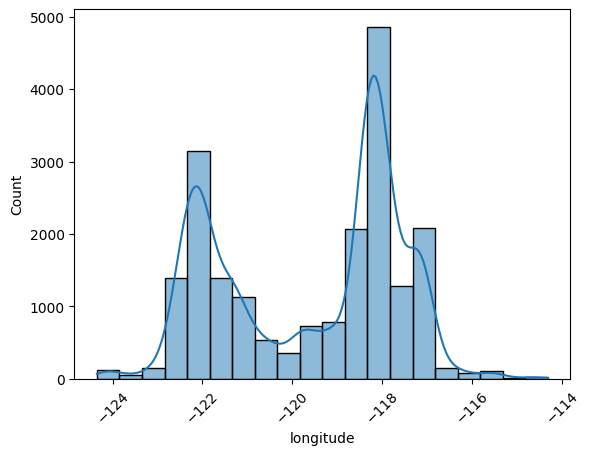

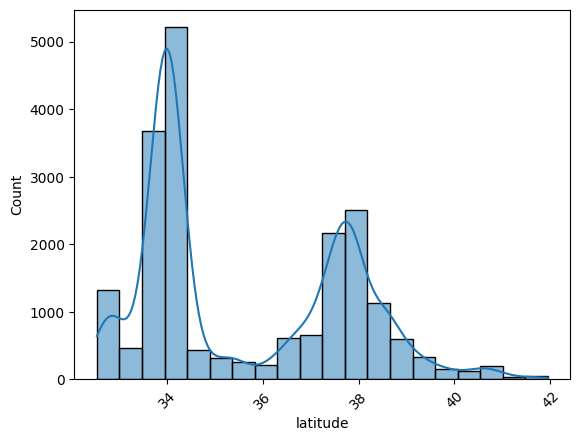

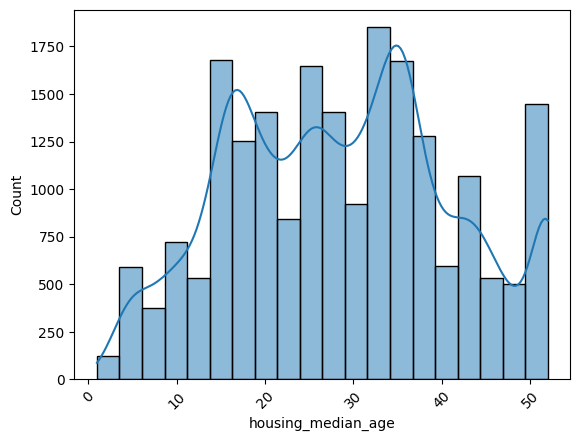

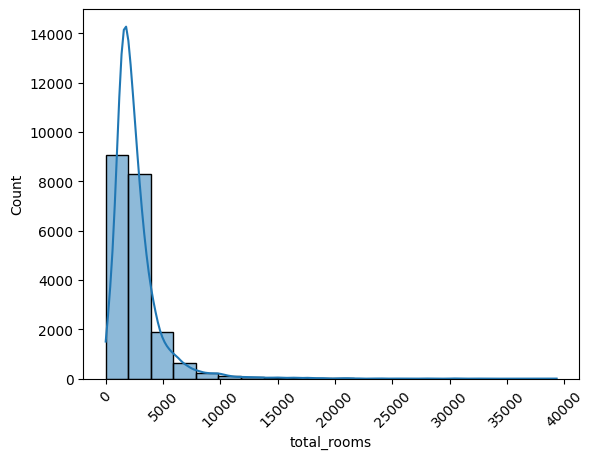

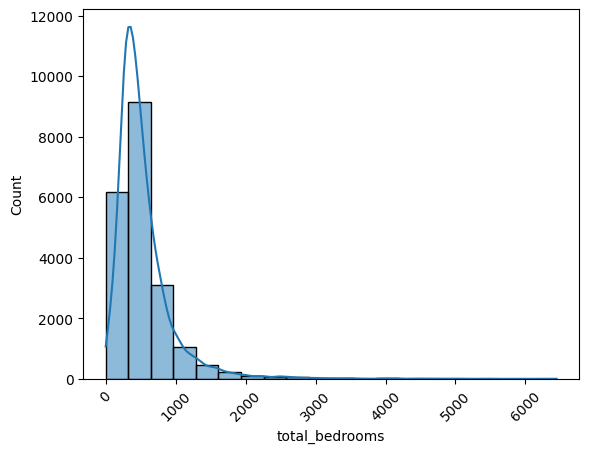

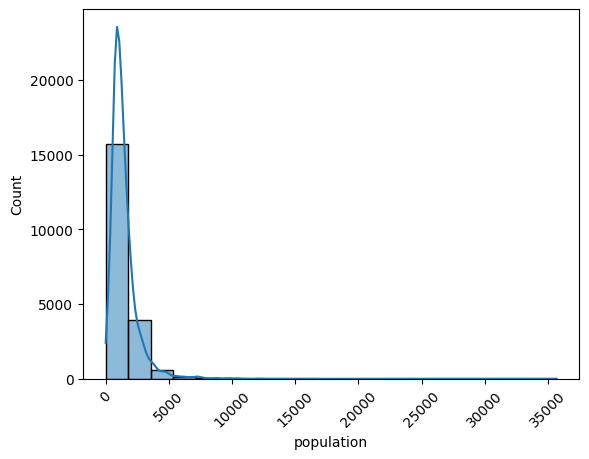

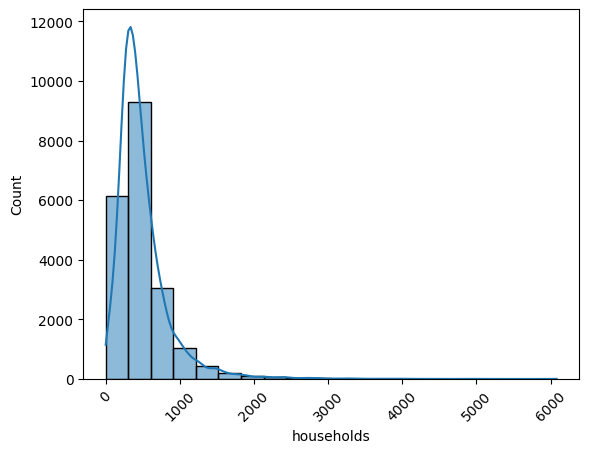

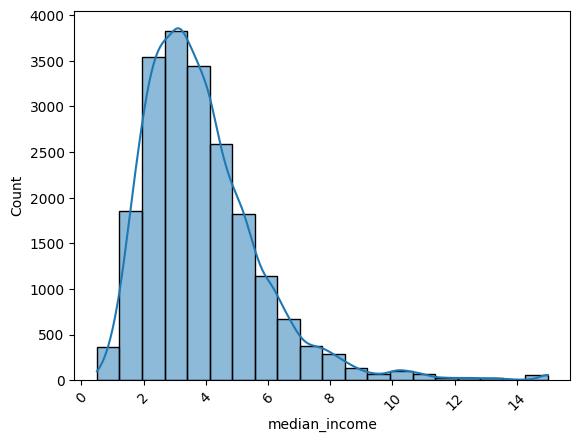

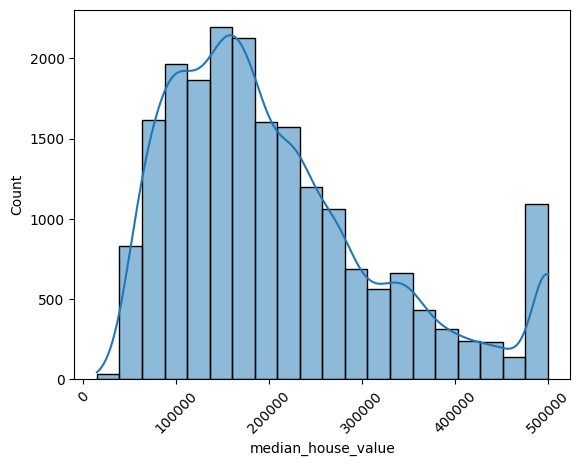

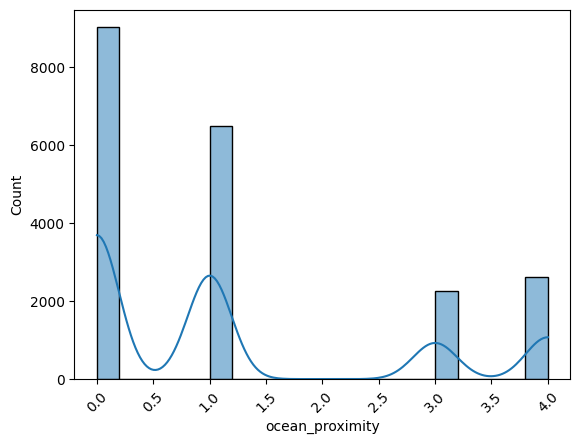

In [10]:
for i in df.columns:
    sns.histplot(data=df, x=i,kde=True, bins=20)
    plt.xticks(rotation=45)
    plt.show()

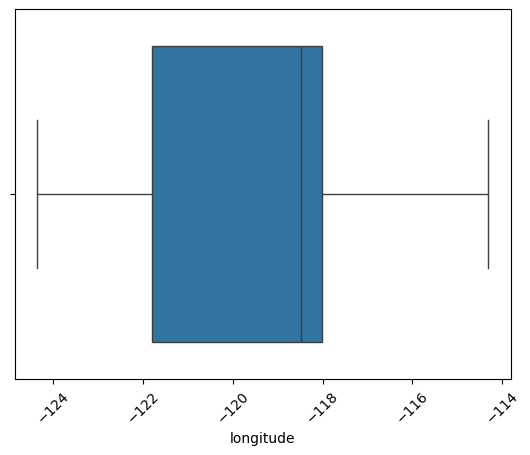

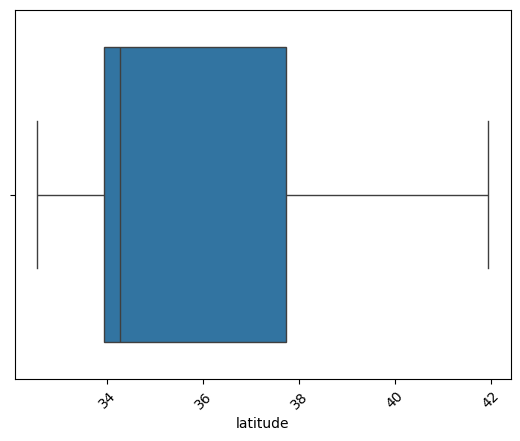

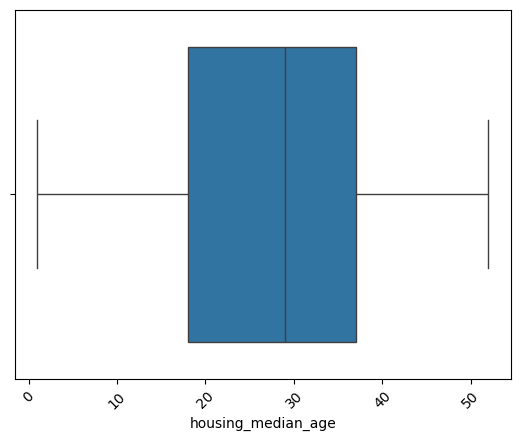

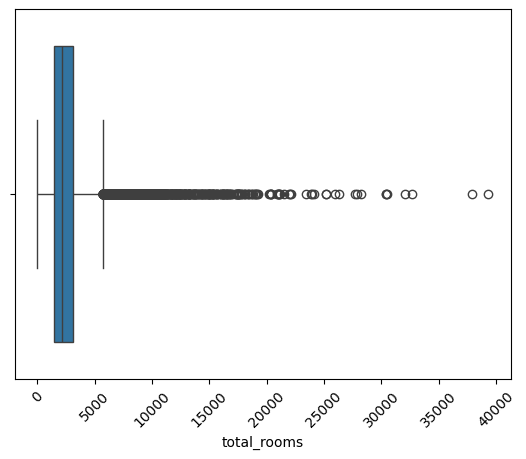

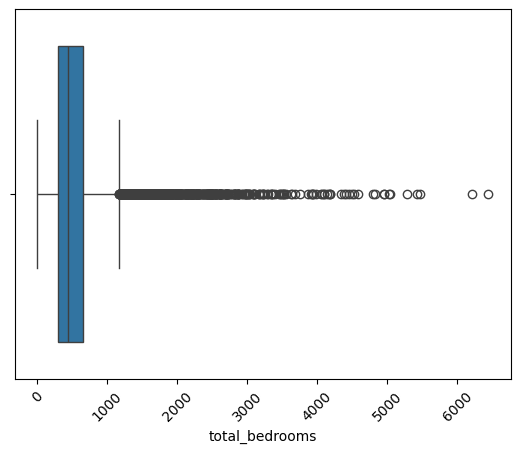

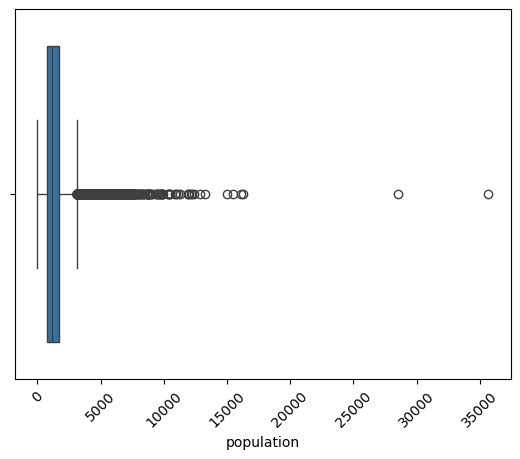

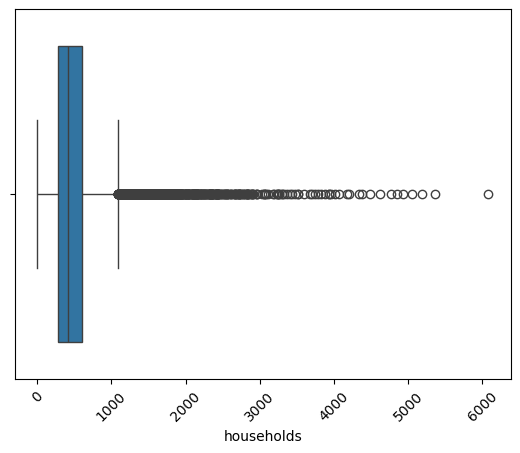

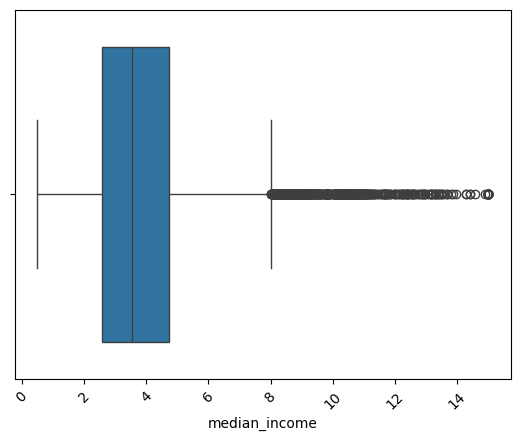

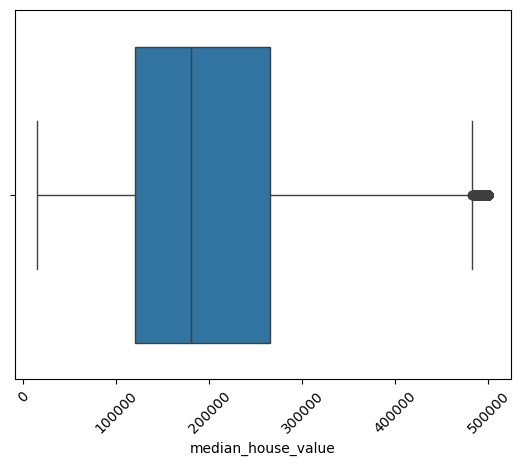

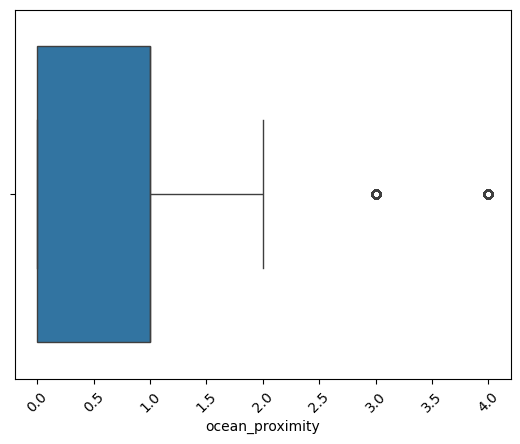

In [11]:
for i in df.columns:
    sns.boxplot(data=df, x=i)
    plt.xticks(rotation=45)
    plt.show()

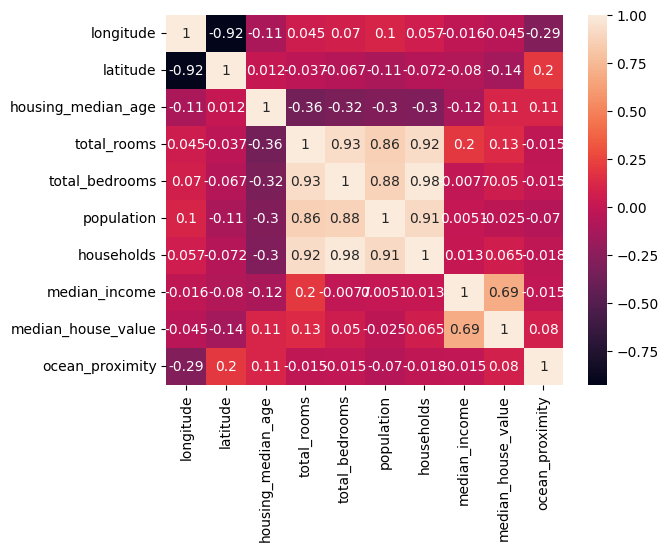

In [12]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [13]:
y = df.median_house_value
x = df.drop('median_house_value', axis=1)

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [15]:
min_max = MinMaxScaler()
x_train = min_max.fit_transform(x_train)
x_test = min_max.transform(x_test)

In [16]:
class PriceModel(nn.Module):
    def __init__(self,in_par):
        super(PriceModel,self).__init__()
        self.flat = nn.Flatten()
        self.seq = nn.Sequential(
            nn.Linear(in_par, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16,1)      
            )
    
    def forward(self, x):
        x1 = self.flat(x)
        return self.seq(x1)

In [17]:
x_train_tensor = torch.tensor(data=x_train, dtype=torch.float32)
x_test_tensor = torch.tensor(data=x_test, dtype=torch.float32)
y_train_tensor = torch.tensor(data=y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(data=y_test.values, dtype=torch.float32)

In [18]:
train_df = TensorDataset(x_train_tensor, y_train_tensor)
test_df = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_df,batch_size=32, shuffle=True)
test_loader = DataLoader(test_df, batch_size=32, shuffle=False)

In [19]:
x_train.shape

(16346, 9)

In [20]:
model = PriceModel(in_par=9)
model

PriceModel(
  (flat): Flatten(start_dim=1, end_dim=-1)
  (seq): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [21]:
criteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [22]:
epochs =20

for ep in range(epochs):
    
    model.train()
    run_loss = 0.0

    for ip, target in train_loader:
        optimizer.zero_grad()
        op = model(ip)
        loss = criteria(op, target)
        loss.backward()
        optimizer.step()
        run_loss += loss.item()
    
    ep_loss = run_loss/len(train_loader.dataset)

    if(ep+1)%1 == 0:
        print(f"Epoch [{ep+1}/{epochs}], Loss: {ep_loss:.4f}")

C:\Users\Nayan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([32])) that is different to the input size (torch.Size([32, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\Nayan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([26])) that is different to the input size (torch.Size([26, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/20], Loss: 1576767216.8085
Epoch [2/20], Loss: 545376982.4975
Epoch [3/20], Loss: 474408222.9781
Epoch [4/20], Loss: 470622884.6005
Epoch [5/20], Loss: 466254414.5885
Epoch [6/20], Loss: 465321351.2199
Epoch [7/20], Loss: 464560435.2752
Epoch [8/20], Loss: 464360849.4311
Epoch [9/20], Loss: 462750124.3685
Epoch [10/20], Loss: 463037469.6625
Epoch [11/20], Loss: 462244402.8367
Epoch [12/20], Loss: 462105743.3324
Epoch [13/20], Loss: 462467314.7505
Epoch [14/20], Loss: 462751562.1094
Epoch [15/20], Loss: 460946820.8707
Epoch [16/20], Loss: 461901978.6086
Epoch [17/20], Loss: 461606225.1570
Epoch [18/20], Loss: 461110137.4692
Epoch [19/20], Loss: 461332229.1369
Epoch [20/20], Loss: 461711339.7969


In [23]:
model.eval()
with torch.no_grad():
    preds = model(x_train_tensor)

    # loss (correct)
    test_loss = criteria(preds, y_train_tensor.view(-1))
    print(f"\n✅ Train Loss: {test_loss.item():.4f}")

    # convert logits → predicted class
    predicted_classes = torch.argmax(preds, dim=1)

    # convert to numpy
    y_true = y_train_tensor.view(-1).cpu().numpy()
    y_pred = predicted_classes.cpu().numpy()

C:\Users\Nayan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([16346])) that is different to the input size (torch.Size([16346, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



✅ Train Loss: 13349842944.0000


C:\Users\Nayan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([4087])) that is different to the input size (torch.Size([4087, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


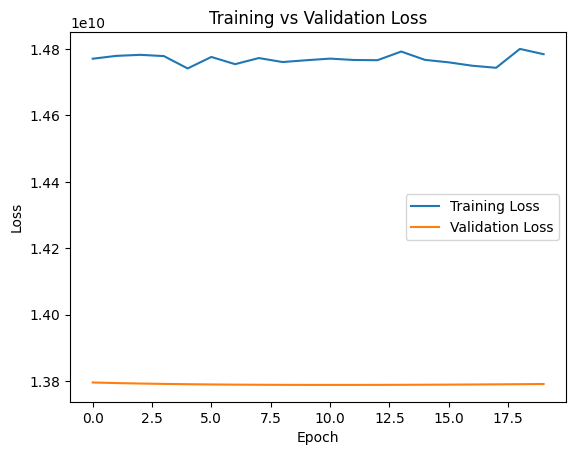

In [24]:
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ---- Training ----
    model.train()
    optimizer.zero_grad()
    
    outputs = model(x_train_tensor)
    loss = criteria(outputs, y_train_tensor)
    
    loss.backward()
    optimizer.step()
    
    train_losses.append(loss.item())

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        val_outputs = model(x_test_tensor)
        val_loss = criteria(val_outputs, y_test_tensor.view(-1))
        val_losses.append(val_loss.item())
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()